# Day 07 - Feature Engineering

Feature engineering means creating NEW columns from existing ones.
The idea is: sometimes a combination of two columns tells more than each column alone.

Example:
- Income = 5000 and Debt = 4000 seems risky
- Income = 5000 and Debt = 500 seems safe
- A debt-to-income ratio captures this relationship in ONE column

Today we will create:
1. Debt to income ratio
2. Total late payments (combine all 3 late payment columns)
3. Is ever late flag (has this person EVER been late?)
4. Income per dependent

We also check if the new features are better predictors than the old ones.

## Step 1 - Import and load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the cleaned data from Day 03
# We use day3 cleaned because day6 was already scaled
# Feature engineering should happen on unscaled data
df = pd.read_csv('cs-training-day3-cleaned.csv', index_col=0)
print('Shape:', df.shape)

Shape: (149999, 12)


In [3]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,income_is_missing
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
5,0,0.907239,49,1,0.024926,23000.0,7,0,1,0,0.0,0


## Step 2 - Create Feature 1: Debt to Income Ratio

DebtRatio already exists but it uses monthly debt / monthly income.
The problem is income has missing values.
Let us create a cleaner version using the filled income column.

In [5]:
# Avoid dividing by zero - add a small number to income
df['debt_to_income'] = df['DebtRatio'] * df['MonthlyIncome'] / (df['MonthlyIncome'] + 1)

In [6]:
# Look at it
df['debt_to_income'].describe()

count    149999.000000
mean        299.896518
std         885.856138
min           0.000000
25%           0.166861
50%           0.357737
75%           0.801116
max        4978.158119
Name: debt_to_income, dtype: float64

In [7]:
# Is it correlated with default?
print('Correlation with default:')
print('debt_to_income:', df['debt_to_income'].corr(df['SeriousDlqin2yrs']))
print('DebtRatio (original):', df['DebtRatio'].corr(df['SeriousDlqin2yrs']))

Correlation with default:
debt_to_income: -0.016657201940454513
DebtRatio (original): -0.017429677554678533


## Step 3 - Create Feature 2: Total Late Payments

We have 3 late payment columns:
- 30-59 days late
- 60-89 days late
- 90+ days late

They are correlated with each other (we found this on Day 05).
Let us combine them into one total late payments column.
This reduces redundancy and might be a stronger signal.

In [8]:
df['total_late_payments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)

In [9]:
df['total_late_payments'].describe()

count    149999.000000
mean          0.453783
std           1.664806
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          30.000000
Name: total_late_payments, dtype: float64

In [20]:
# How does total late payments distribute between defaulters vs non-defaulters?
defaulters = df[df['SeriousDlqin2yrs'] == 1]
non_defaulters = df[df['SeriousDlqin2yrs'] == 0]

print('Avg total late payments - defaulters:', defaulters['total_late_payments'].mean())
print('Avg total late payments - non defaulters:', non_defaulters['total_late_payments'].mean())

Avg total late payments - defaulters: 2.436664671853182
Avg total late payments - non defaulters: 0.3117529809320369


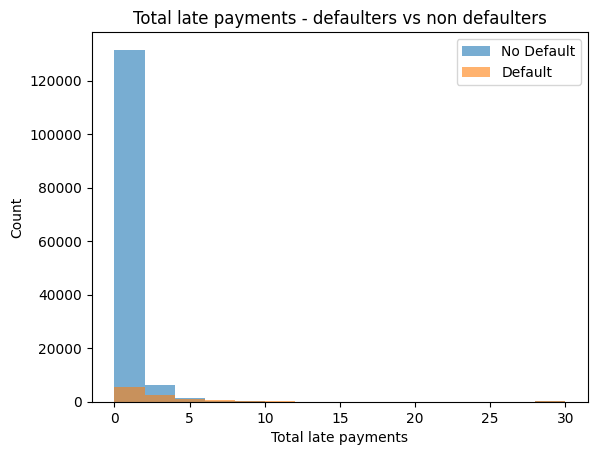

In [21]:
# Plot it
plt.hist(non_defaulters['total_late_payments'], bins=15, alpha=0.6, label='No Default')
plt.hist(defaulters['total_late_payments'], bins=15, alpha=0.6, label='Default')
plt.title('Total late payments - defaulters vs non defaulters')
plt.xlabel('Total late payments')
plt.ylabel('Count')
plt.legend()
plt.show()

## Step 4 - Create Feature 3: Ever Late Flag

Has this person EVER been late on any payment?
Simple yes/no - 1 if they have any late payment, 0 if they never missed

In [12]:
df['ever_late'] = (df['total_late_payments'] > 0).astype(int)

In [13]:
df['ever_late'].value_counts()

ever_late
0    119637
1     30362
Name: count, dtype: int64

In [14]:
# What percentage of each group defaulted?
print('Default rate if NEVER late:', df[df['ever_late']==0]['SeriousDlqin2yrs'].mean() * 100, '%')
print('Default rate if EVER late:', df[df['ever_late']==1]['SeriousDlqin2yrs'].mean() * 100, '%')

Default rate if NEVER late: 2.7282529652197898 %
Default rate if EVER late: 22.27126012779132 %


Write down what you see here. Is ever_late a strong predictor?

## Step 5 - Create Feature 4: Income Per Dependent

How much income does each family member have?
Low income + many dependents = more financial pressure

In [15]:
# Avoid dividing by 0 - add 1 to dependents
df['income_per_dependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

In [16]:
df['income_per_dependent'].describe()

count    149999.000000
mean       4422.384444
std        3180.155310
min           0.000000
25%        2151.000000
50%        4000.000000
75%        5400.000000
max       23000.000000
Name: income_per_dependent, dtype: float64

In [22]:
print('Avg income per dependent - defaulters:', defaulters['income_per_dependent'].mean())
print('Avg income per dependent - non defaulters:', non_defaulters['income_per_dependent'].mean())

Avg income per dependent - defaulters: 3684.270157313208
Avg income per dependent - non defaulters: 4475.254167795904


## Step 6 - Compare all new features vs old features

Are our new features better predictors than the original ones?

In [ ]:
all_features = df.drop(columns=['SeriousDlqin2yrs']).columns

correlations = df[all_features].corrwith(df['SeriousDlqin2yrs']).abs().sort_values(ascending=False)
print('All features ranked by correlation with default:')
print(correlations)

In [ ]:
correlations.plot(kind='bar')
plt.title('Feature correlation with default - new features vs old')
plt.ylabel('Correlation (absolute)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Look at where the new features (total_late_payments, ever_late, debt_to_income, income_per_dependent) rank.
Do any of them beat the original features?

## Step 7 - Save

In [ ]:
print('Columns now:', list(df.columns))

In [ ]:
df.to_csv('cs-training-day7-features.csv')
print('Saved!')
print('Shape:', df.shape)

## My observations today (fill this yourself)

1. Which new feature has the highest correlation with default?
2. Does ever_late have a big difference in default rate between yes/no?
3. Why did we add 1 when calculating income_per_dependent?
4. Can you think of another feature we could create from the existing columns?

---
Tomorrow - Day 08: Handle class imbalance with SMOTE